# Time-dependent optical lattices

An `OptiLat` lattice can be handed to the time-dependent potential classes of the `BECs` package,so that lattice loading, modulation spectroscopy, Floquet shaking and moving lattices are described in terms of the beams that make them rather than by hand-written spatial formulas. Give every beam a complex time factor $c_j(t) = s_j(t)e^{i\phi_j(t)}$, an amplitude ramp times a phase modulation. The field of a coherent layer becomes $$\mathbf{E}_L(\mathbf{r},t) = \sum_{j \in L} c_j(t)\, \mathbf{A}_j\, e^{i\mathbf{k}_j\cdot\mathbf{r}}$$ and squaring it separates space from time *exactly*: $$|\mathbf{E}_L(\mathbf{r},t)|^2 = \sum_j |c_j(t)|^2 |\mathbf{A}_j|^2 + 2\sum_{j<l}\Big( \mathrm{Re}[c_jc_l^*]\,\mathrm{Re}\,G_{jl}(\mathbf{r}) - \mathrm{Im}[c_jc_l^*]\,\mathrm{Im}\,G_{jl}(\mathbf{r}) \Big)$$ with the **static** pairwise grating $G_{jl}(\mathbf{r}) = (\mathbf{A}_j\cdot\mathbf{A}_l^*)\,e^{i(\mathbf{k}_j-\mathbf{k}_l)\cdot\mathbf{r}}$. This is an algebraic identity, so it holds for arbitrary amplitude and phase modulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from bloch_schrodinger.potential import create_parameter
from BECs.potentialT import PotentialT, AnalyticPotential

from optilat import (
    Beam, OptiLat, BeamDrive, LatticeDrive,
    add_to_potentialT, add_to_analytic, field_on, stark_potential
)

lamb = 0.83                                            # Laser wavelength
angles = [np.pi / 2 + 2 * np.pi / 3 * i for i in range(3)]   # The usual 120 deg geometry

def honeycomb_beams(theta=0.4):
    return [
        Beam(wavelength=lamb,
             direction=[np.cos(a), np.sin(a), 0],
             polar=[np.cos(theta), np.sin(theta)])
        for a in angles
    ]

lattice = OptiLat()
lattice.add_beam(honeycomb_beams(), [0] * 3)   # One coherent layer: the three beams interfere

The static landscape, for reference`field_on` evaluates the beams on a potential's own cartesian grid, whatever its dimensionality,and `stark_potential` turns the complex amplitudes into the AC-Stark shift$$V = -\tfrac14\left[\alpha_s|\mathbf{E}|^2 + \frac{\alpha_v M}{2F}\,2\,\mathrm{Im}(E_x^*E_y)\right]$$which is the formula the other notebooks write out by hand.

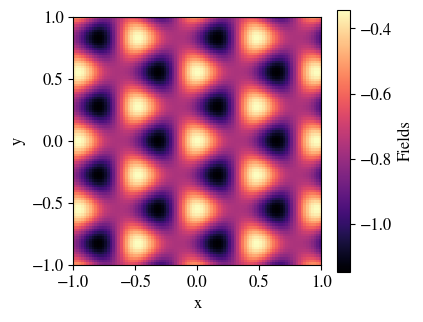

In [2]:
box = PotentialT([[2, 0], [0, 2]], resolution=(96, 96), v0=0)   # v0=0: the lattice is the whole potential
STARK = dict(alpha_s=1.0, alpha_v=0.4, M=3, F=3)

V_static = stark_potential(field_on(lattice, box), **STARK)

fig, ax = plt.subplots(figsize=(4, 3.4))
V_static.plot(x="x", y="y", ax=ax, cmap="magma")
ax.set_aspect("equal")
plt.show()

## Loading the lattice 
A depth ramp `BeamDrive.ramp` ramps the beams. `on="depth"` means the *potential* follows the ramp, which is what a lattice depth in recoil units refers to; the field amplitude then carries its square root. Giving the same drive to all three beams keeps the pattern fixed and only changes its contrast.`add_to_potentialT` registers one shape and one time function per grating, plus one term summing them. Everything the potential already held is left alone, so a trap in `V0` or a shape added with `circle_t` simply adds to the lattice.

In [3]:
loading = PotentialT([[2, 0], [0, 2]], resolution=(96, 96), v0=0)

drive = LatticeDrive(lattice)
drive[:] = BeamDrive.ramp(vi=0.0, vf=1.0, ti=0.1, tf=2.0, on="depth")

expansion = add_to_potentialT(loading, lattice, drive, **STARK)
print(f"{len(expansion.gratings)} gratings registered:", [g.name for g in expansion.gratings])

Vt = loading.make_Vt({})            # The fast V(t) the solvers use
print("depth at t = 0, 1, 2:", [round(float(abs(Vt(t)).max()), 3) for t in (0, 1, 2)])

15 gratings registered: ['s0_0_re', 's0_1_re', 's0_1_im', 'v0_1_re', 'v0_1_im', 's0_2_re', 's0_2_im', 'v0_2_re', 'v0_2_im', 's1_1_re', 's1_2_re', 's1_2_im', 'v1_2_re', 'v1_2_im', 's2_2_re']
depth at t = 0, 1, 2: [0.0, 0.527, 1.145]


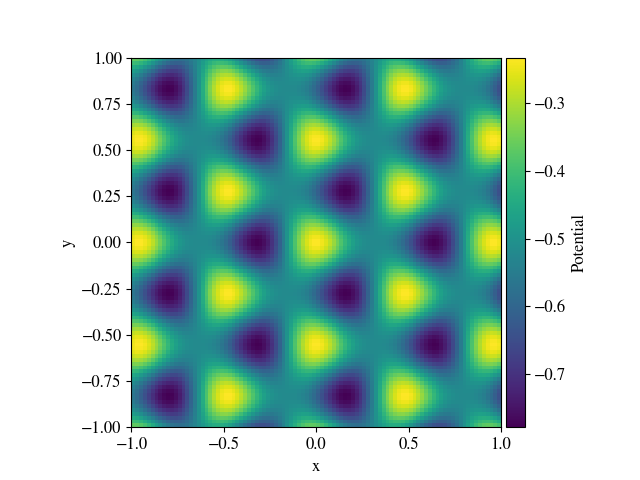

In [4]:
%matplotlib widget
loading.plot_t(0, 2.5, n_t=40)
plt.show()

## Shaking the lattice

`BeamDrive.shake` modulates the *phase* of a beam, which displaces the interference pattern without changing its depth: the Floquet drive of a shaken lattice. Any drive argument given as a`create_parameter` array becomes a parameter dimension of the potential, and is therefore swept by the solvers exactly like a polarizability or an interaction strength.

parameter dimensions the solvers will iterate over: {'nu': <xarray.DataArray 'nu' (nu: 7)> Size: 56B
array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. ])
Coordinates:
  * nu       (nu) float64 56B 1.0 1.5 2.0 2.5 3.0 3.5 4.0}


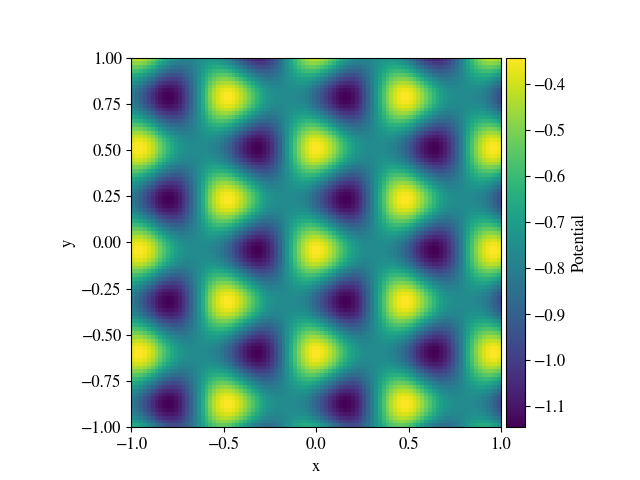

In [5]:
nu = create_parameter("nu", np.linspace(1.0, 4.0, 7))     # The shaking frequency, swept

shaken = PotentialT([[2, 0], [0, 2]], resolution=(96, 96), v0=0)

drive = LatticeDrive(lattice)
drive[[1, 2]] = BeamDrive.shake(amp=0.6, freq=nu)         # Two beams shaken, one left as a reference

add_to_potentialT(shaken, lattice, drive, **STARK)
print("parameter dimensions the solvers will iterate over:", dict(shaken.param_coords))

shaken.plot_t(0, 1.5, n_t=60)
plt.show()

A single beam detuned from its partners makes the pattern travel instead of oscillate:`BeamDrive.move(detuning)` translates the lattice at a speed $2\pi\delta/|k|$.

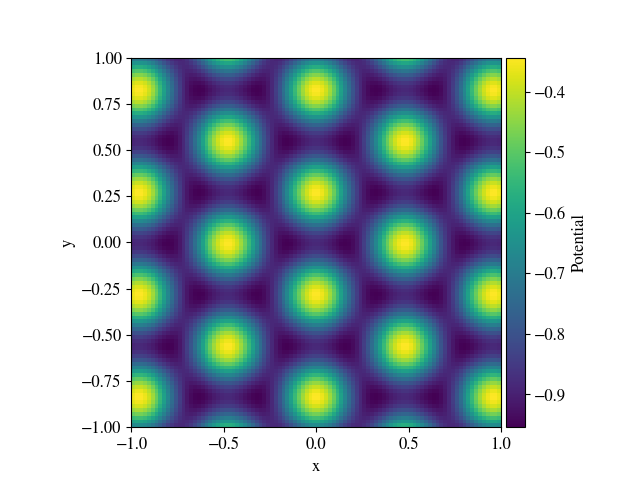

In [6]:
moving = PotentialT([[2, 0], [0, 2]], resolution=(96, 96), v0=0)

drive = LatticeDrive(lattice)
drive[0] = BeamDrive.move(detuning=create_parameter("delta", np.linspace(0.0, 2.0, 5)))

add_to_potentialT(moving, lattice, drive, alpha_s=1.0)
moving.plot_t(0, 1.0, n_t=40)
plt.show()

## The two faster routes

`mode="stacked"` keeps the gratings in a single array and combines them with one tensor contraction, which costs several times less per time step. The price is that the array is fixed once and for all, so the beams may not carry parameter dimensions of their own (drive parameters are still swept). `add_to_analytic` takes the other extreme and stores no grating at all: it registers one function of time and coordinates, recomputing the beam sum in numpy wherever it is asked to. That is what the rescaling solver needs, since its grid changes at every step, and it is also the route to take when the gratings would not fit in memory — they cost `n_gratings x grid`.

In [7]:
import time

def cost(V, n=100):
    V(0.0)
    t0 = time.perf_counter()
    for i in range(n):
        V(i * 1e-3)
    return (time.perf_counter() - t0) / n * 1e3

drive = LatticeDrive(lattice)
drive[[1, 2]] = BeamDrive.shake(amp=0.6, freq=2.5)

shapes = PotentialT([[2, 0], [0, 2]], (128, 128), v0=0)
add_to_potentialT(shapes, lattice, drive, mode="shapes", **STARK)

stacked = PotentialT([[2, 0], [0, 2]], (128, 128), v0=0)
add_to_potentialT(stacked, lattice, drive, mode="stacked", **STARK)

analytic = AnalyticPotential([[2, 0], [0, 2]], (128, 128))
add_to_analytic(analytic, lattice, drive, **STARK)

print(f"shapes   {cost(shapes.make_Vt({})):.2f} ms/step")
print(f"stacked  {cost(stacked.make_Vt({})):.2f} ms/step")
print(f"analytic {cost(analytic.make_V({})):.2f} ms/step")

# All three describe the very same potential
a, b, c = (np.asarray(v(0.31)) for v in
           (shapes.make_Vt({}), stacked.make_Vt({}), analytic.make_V({})))
print("agreement:", abs(a - b).max(), abs(a - c).max())

shapes   4.50 ms/step
stacked  0.92 ms/step
analytic 0.96 ms/step
agreement: 4.440892098500626e-16 1.1102230246251565e-15


## Feeding it to the solver

Nothing further is needed: a `PotentialT` carrying lattice terms is an ordinary `PotentialT`, and its drive parameters are run dimensions like any other. Below, a cloud is propagated in a shaken lattice at several shaking frequencies at once. Note that the grid has to resolve the lattice period, $\lambda/2 \approx 0.42$ here: a spatially under-resolved lattice aliases in the kinetic step and shows up as a drifting norm.

In [8]:
from BECs.ssfm import SSFM

nu = create_parameter("nu", np.array([1.0, 3.0]))

run = PotentialT([[2, 0], [0, 2]], resolution=(64, 64), v0=0)
drive = LatticeDrive(lattice)
drive[[1, 2]] = BeamDrive.shake(amp=0.6, freq=nu)
add_to_potentialT(run, lattice, drive, alpha_s=30.0)

psi0 = xr.ones_like(run.V, dtype=complex) / (run.n_elems * run.get_dS()) ** 0.5

solver = SSFM(run, psi0, g=0.0)
t_samples = create_parameter("t", np.linspace(0, 0.5, 5))
psi = solver.solve(0.0, 0.5, t_samples, dt0=1e-4, tol=1e-9)

norm = (abs(psi) ** 2).sum(["a1", "a2"]) * run.get_dS()
print("largest deviation of the norm:", float(abs(norm - 1).max()))
psi

Propagating the initial states. 2 iterations to perform


KeyboardInterrupt: 